# Задание

Используя набор данных <a href='https://www.kaggle.com/unsdsn/world-happiness?select=2017.csv'>World Happiness Report 2017</a> визуализировать:
1. Топ-5 стран с наивысшими рейтингами по каждому континенту, расположив их на одном мультиокне;
2. График зависимости уровня свободы от уровня счастья, указав на графике отклонения при помощи box whisker chart;
3. Облако точек зависимости уровня "счастья" от уровня ВВП страны;
4. Распределение по столбцу Family для различных значений уровня "счастья";
5. Добавить в набор данных столбец с указанием экономического мира страны ("первый мир", "второй мир" и "третий мир") и визуализировать топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров.


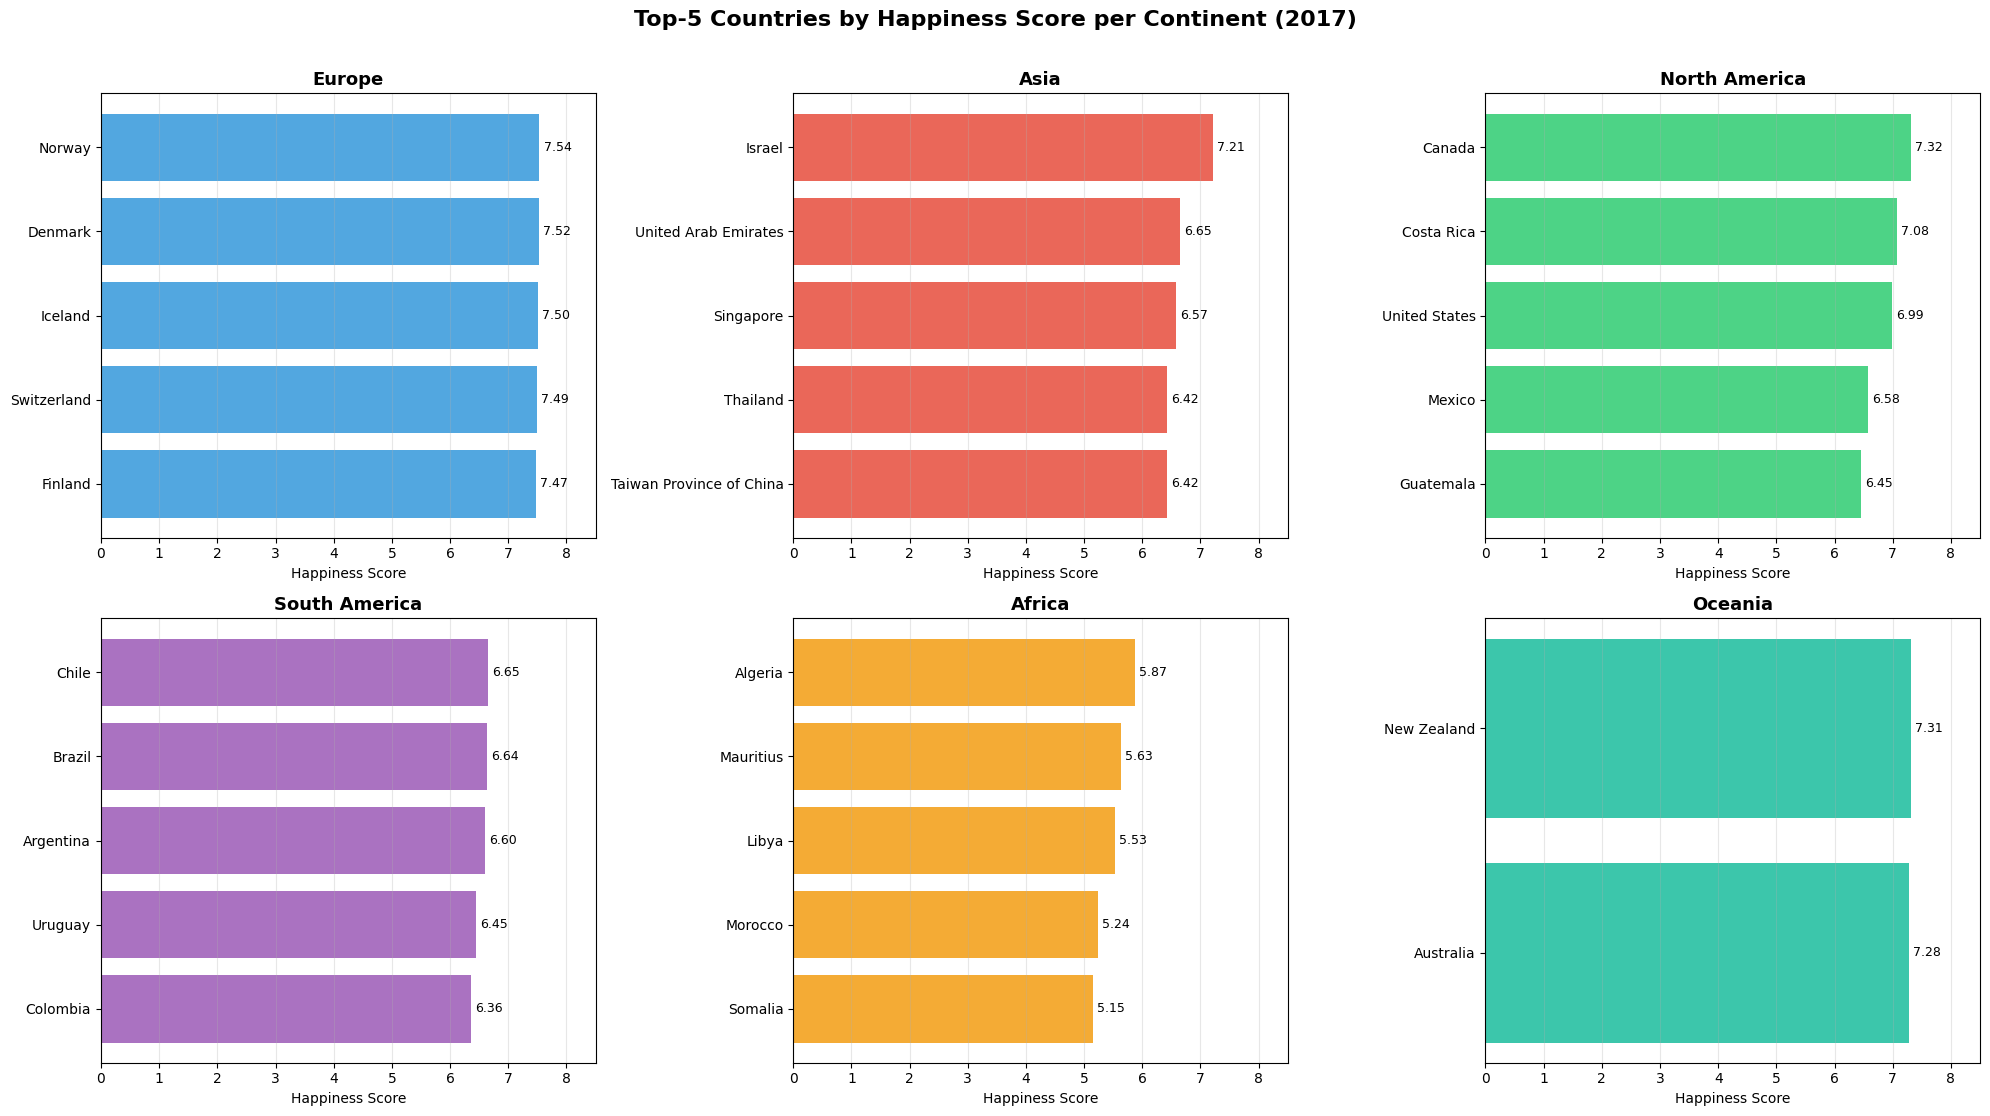

In [6]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Загрузка данных
df = pd.read_csv('World_Happiness_Report_2017.csv')

# Маппинг
continent_map = {
    'Norway': 'Europe', 'Denmark': 'Europe', 'Iceland': 'Europe',
    'Switzerland': 'Europe', 'Finland': 'Europe', 'Netherlands': 'Europe',
    'Canada': 'North America', 'New Zealand': 'Oceania', 'Sweden': 'Europe',
    'Australia': 'Oceania', 'Israel': 'Asia', 'Costa Rica': 'North America',
    'Austria': 'Europe', 'United States': 'North America', 'Ireland': 'Europe',
    'Germany': 'Europe', 'Belgium': 'Europe', 'Luxembourg': 'Europe',
    'United Kingdom': 'Europe', 'Chile': 'South America',
    'United Arab Emirates': 'Asia', 'Brazil': 'South America',
    'Czech Republic': 'Europe', 'Argentina': 'South America',
    'Mexico': 'North America', 'Singapore': 'Asia', 'Malta': 'Europe',
    'Uruguay': 'South America', 'Guatemala': 'North America',
    'Panama': 'North America', 'France': 'Europe', 'Thailand': 'Asia',
    'Taiwan Province of China': 'Asia', 'Spain': 'Europe', 'Qatar': 'Asia',
    'Colombia': 'South America', 'Saudi Arabia': 'Asia',
    'Trinidad and Tobago': 'North America', 'Kuwait': 'Asia',
    'Slovakia': 'Europe', 'Bahrain': 'Asia', 'Malaysia': 'Asia',
    'Nicaragua': 'North America', 'Ecuador': 'South America',
    'El Salvador': 'North America', 'Poland': 'Europe', 'Uzbekistan': 'Asia',
    'Italy': 'Europe', 'Russia': 'Europe', 'Belize': 'North America',
    'Japan': 'Asia', 'Lithuania': 'Europe', 'Algeria': 'Africa',
    'Latvia': 'Europe', 'South Korea': 'Asia', 'Moldova': 'Europe',
    'Romania': 'Europe', 'Bolivia': 'South America', 'Turkmenistan': 'Asia',
    'Kazakhstan': 'Asia', 'North Cyprus': 'Europe', 'Slovenia': 'Europe',
    'Peru': 'South America', 'Mauritius': 'Africa', 'Cyprus': 'Europe',
    'Estonia': 'Europe', 'Belarus': 'Europe', 'Libya': 'Africa',
    'Turkey': 'Asia', 'Paraguay': 'South America',
    'Hong Kong S.A.R., China': 'Asia', 'Philippines': 'Asia',
    'Serbia': 'Europe', 'Jordan': 'Asia', 'Hungary': 'Europe',
    'Jamaica': 'North America', 'Croatia': 'Europe', 'Kosovo': 'Europe',
    'China': 'Asia', 'Pakistan': 'Asia', 'Indonesia': 'Asia',
    'Venezuela': 'South America', 'Montenegro': 'Europe', 'Morocco': 'Africa',
    'Azerbaijan': 'Asia', 'Dominican Republic': 'North America',
    'Greece': 'Europe', 'Lebanon': 'Asia', 'Portugal': 'Europe',
    'Bosnia and Herzegovina': 'Europe', 'Honduras': 'North America',
    'Macedonia': 'Europe', 'Somalia': 'Africa', 'Vietnam': 'Asia',
    'Nigeria': 'Africa', 'Tajikistan': 'Asia', 'Bhutan': 'Asia',
    'Kyrgyzstan': 'Asia', 'Nepal': 'Asia', 'Mongolia': 'Asia',
    'South Africa': 'Africa', 'Tunisia': 'Africa',
    'Palestinian Territories': 'Asia', 'Egypt': 'Africa', 'Bulgaria': 'Europe',
    'Sierra Leone': 'Africa', 'Cameroon': 'Africa', 'Iran': 'Asia',
    'Albania': 'Europe', 'Bangladesh': 'Asia', 'Namibia': 'Africa',
    'Kenya': 'Africa', 'Mozambique': 'Africa', 'Myanmar': 'Asia',
    'Senegal': 'Africa', 'Zambia': 'Africa', 'Iraq': 'Asia',
    'Gabon': 'Africa', 'Ethiopia': 'Africa', 'Sri Lanka': 'Asia',
    'Armenia': 'Asia', 'India': 'Asia', 'Mauritania': 'Africa',
    'Congo (Brazzaville)': 'Africa', 'Georgia': 'Asia',
    'Congo (Kinshasa)': 'Africa', 'Mali': 'Africa', 'Ivory Coast': 'Africa',
    'Cambodia': 'Asia', 'Sudan': 'Africa', 'Ghana': 'Africa',
    'Ukraine': 'Europe', 'Uganda': 'Africa', 'Burkina Faso': 'Africa',
    'Niger': 'Africa', 'Malawi': 'Africa', 'Chad': 'Africa',
    'Zimbabwe': 'Africa', 'Lesotho': 'Africa', 'Angola': 'Africa',
    'Afghanistan': 'Asia', 'Botswana': 'Africa', 'Benin': 'Africa',
    'Madagascar': 'Africa', 'Haiti': 'North America', 'Yemen': 'Asia',
    'South Sudan': 'Africa', 'Liberia': 'Africa', 'Guinea': 'Africa',
    'Togo': 'Africa', 'Rwanda': 'Africa', 'Syria': 'Asia',
    'Tanzania': 'Africa', 'Burundi': 'Africa',
    'Central African Republic': 'Africa',
}

df['Continent'] = df['Country'].map(continent_map)

# 1. Топ-5 стран по континентам
continents = ['Europe', 'Asia', 'North America', 'South America', 'Africa', 'Oceania']
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Top-5 Countries by Happiness Score per Continent (2017)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, continent, color in zip(axes.flatten(), continents, colors):
    top5 = df[df['Continent'] == continent].nlargest(5, 'Happiness.Score')
    bars = ax.barh(range(len(top5)), top5['Happiness.Score'], color=color, alpha=0.85)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5['Country'], fontsize=10)
    ax.set_title(continent, fontsize=13, fontweight='bold')
    ax.set_xlabel('Happiness Score', fontsize=10)
    ax.set_xlim(0, 8.5)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, top5['Happiness.Score'])):
        ax.text(val + 0.07, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


C:\Users\011ko\AppData\Local\Temp\ipykernel_24572\2520413672.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(group_data, labels=labels, patch_artist=True, notch=False,


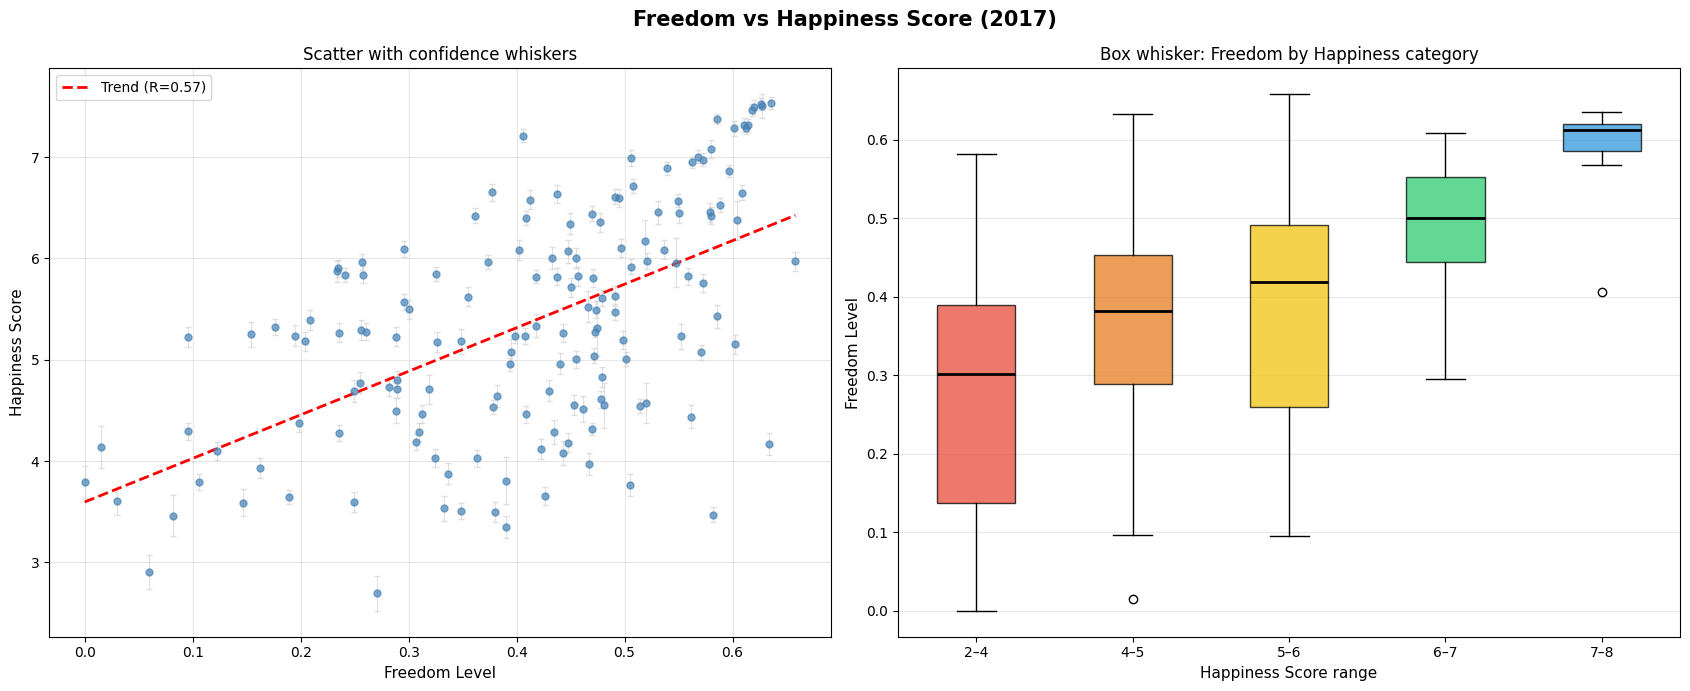

In [7]:
# 2. Зависимость ур-я свободы от ур-я счастья

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Freedom vs Happiness Score (2017)', fontsize=15, fontweight='bold')

err_low  = df['Happiness.Score'] - df['Whisker.low']
err_high = df['Whisker.high']    - df['Happiness.Score']

ax1.errorbar(
    df['Freedom'], df['Happiness.Score'],
    yerr=[err_low, err_high],
    fmt='o', color='steelblue', ecolor='lightgray',
    elinewidth=0.8, capsize=2, alpha=0.7, markersize=5
)
z = np.polyfit(df['Freedom'], df['Happiness.Score'], 1)
x_fit = np.linspace(df['Freedom'].min(), df['Freedom'].max(), 200)
ax1.plot(x_fit, np.poly1d(z)(x_fit), 'r--', linewidth=2, label=f'Trend (R={np.corrcoef(df["Freedom"], df["Happiness.Score"])[0,1]:.2f})')
ax1.set_xlabel('Freedom Level', fontsize=11)
ax1.set_ylabel('Happiness Score', fontsize=11)
ax1.set_title('Scatter with confidence whiskers', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

bins   = [2, 4, 5, 6, 7, 8]
labels = ['2–4', '4–5', '5–6', '6–7', '7–8']
df['Hap_Cat'] = pd.cut(df['Happiness.Score'], bins=bins, labels=labels)

group_data = [df[df['Hap_Cat'] == lbl]['Freedom'].dropna().values for lbl in labels]

bp = ax2.boxplot(group_data, labels=labels, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
box_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB']
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax2.set_xlabel('Happiness Score range', fontsize=11)
ax2.set_ylabel('Freedom Level', fontsize=11)
ax2.set_title('Box whisker: Freedom by Happiness category', fontsize=12)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


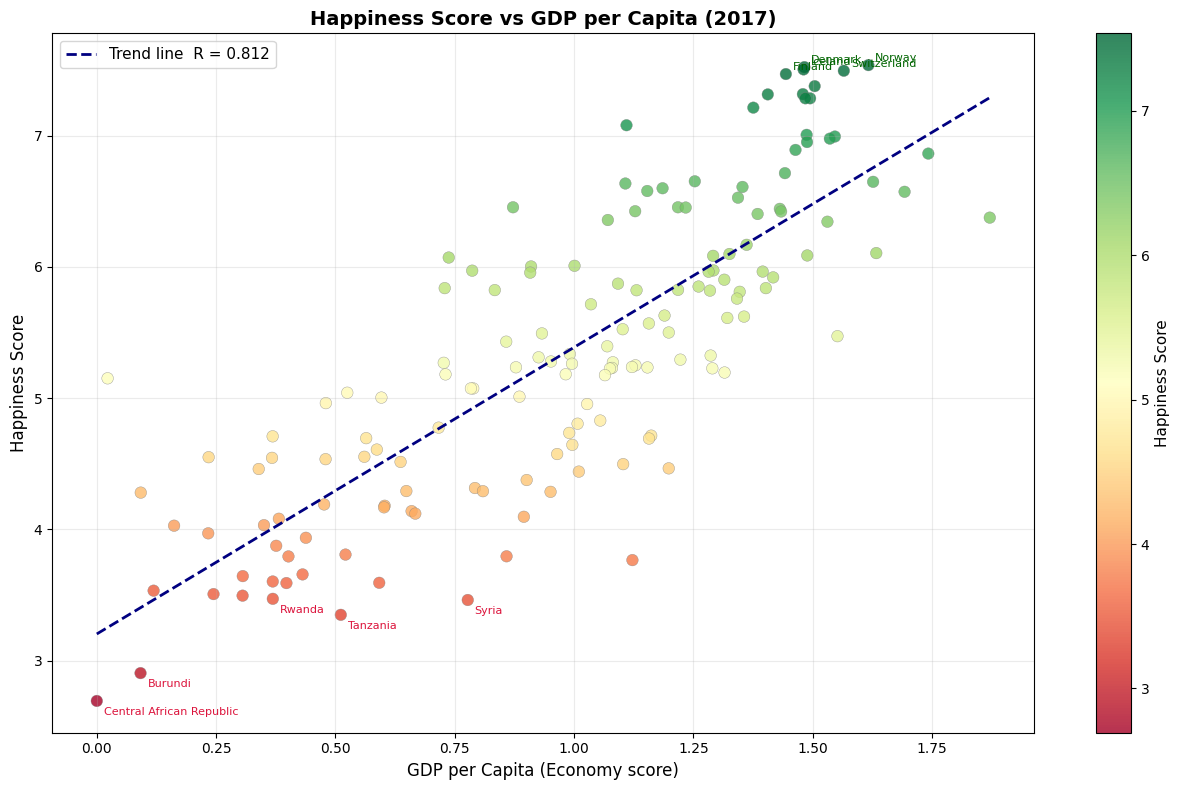

In [8]:
# 3. Облако точек зависимости уровня "счастья" от уровня ВВП страны

fig, ax = plt.subplots(figsize=(13, 8))

sc = ax.scatter(
    df['Economy..GDP.per.Capita.'], df['Happiness.Score'],
    c=df['Happiness.Score'], cmap='RdYlGn',
    s=70, alpha=0.8, edgecolors='gray', linewidth=0.3
)

z = np.polyfit(df['Economy..GDP.per.Capita.'], df['Happiness.Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Economy..GDP.per.Capita.'].min(),
                     df['Economy..GDP.per.Capita.'].max(), 200)
corr = np.corrcoef(df['Economy..GDP.per.Capita.'], df['Happiness.Score'])[0, 1]
ax.plot(x_line, p(x_line), 'navy', linewidth=2, linestyle='--',
        label=f'Trend line  R = {corr:.3f}')

for _, row in df.nlargest(5, 'Happiness.Score').iterrows():
    ax.annotate(row['Country'],
                (row['Economy..GDP.per.Capita.'], row['Happiness.Score']),
                textcoords='offset points', xytext=(5, 3), fontsize=8, color='darkgreen')
for _, row in df.nsmallest(5, 'Happiness.Score').iterrows():
    ax.annotate(row['Country'],
                (row['Economy..GDP.per.Capita.'], row['Happiness.Score']),
                textcoords='offset points', xytext=(5, -10), fontsize=8, color='crimson')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Happiness Score', fontsize=11)
ax.set_xlabel('GDP per Capita (Economy score)', fontsize=12)
ax.set_ylabel('Happiness Score', fontsize=12)
ax.set_title('Happiness Score vs GDP per Capita (2017)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


C:\Users\011ko\AppData\Local\Temp\ipykernel_24572\2101233119.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(groups, labels=['Low', 'Medium', 'High', 'Very High'],


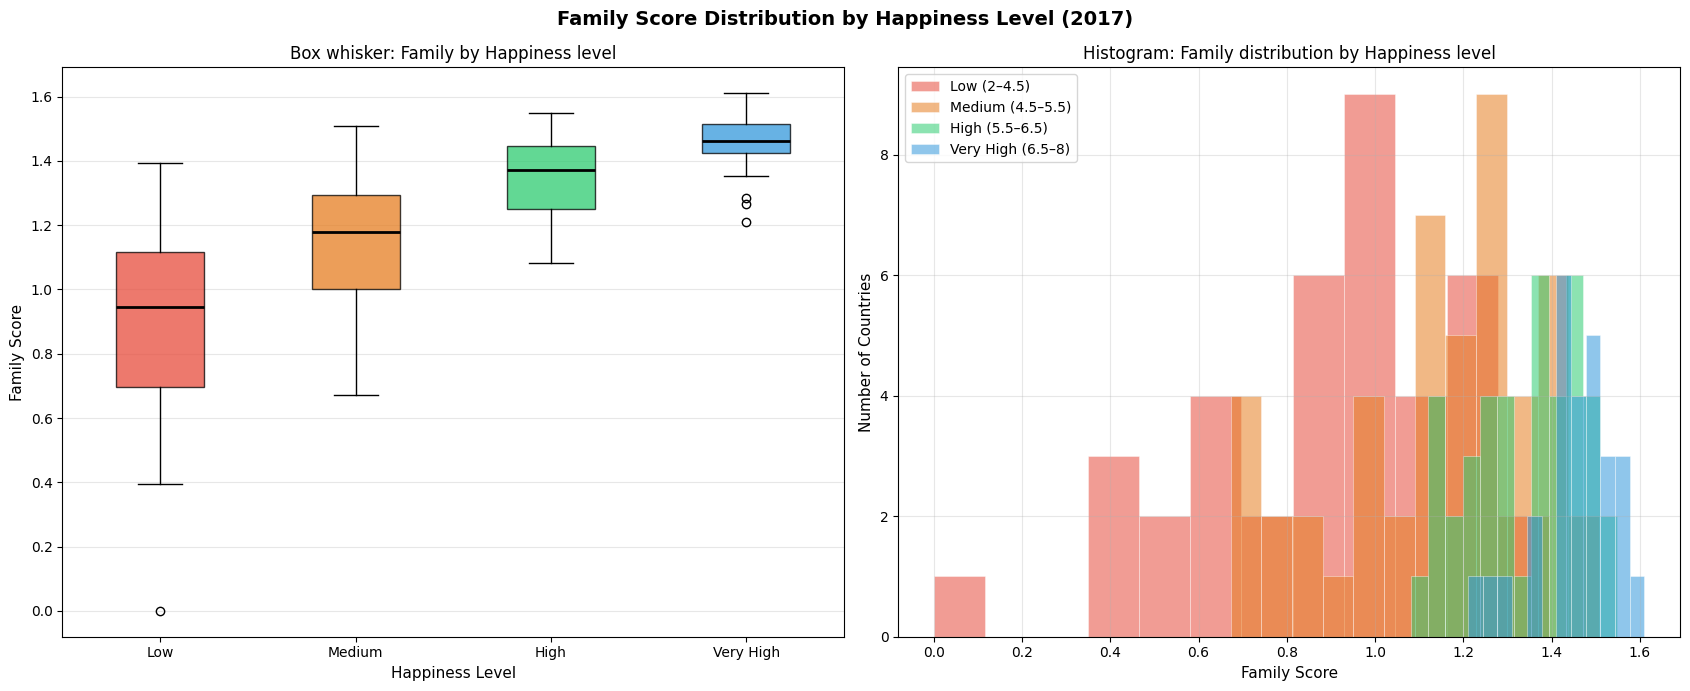

In [9]:
# 4. Распределение по столбцу Family для различных значений уровня "счастья"

bins   = [2.0, 4.5, 5.5, 6.5, 8.0]
labels = ['Low (2–4.5)', 'Medium (4.5–5.5)', 'High (5.5–6.5)', 'Very High (6.5–8)']
df['Hap_Level'] = pd.cut(df['Happiness.Score'], bins=bins, labels=labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Family Score Distribution by Happiness Level (2017)',
             fontsize=14, fontweight='bold')

pal = ['#E74C3C', '#E67E22', '#2ECC71', '#3498DB']

groups = [df[df['Hap_Level'] == lbl]['Family'].dropna().values for lbl in labels]
bp = ax1.boxplot(groups, labels=['Low', 'Medium', 'High', 'Very High'],
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], pal):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax1.set_xlabel('Happiness Level', fontsize=11)
ax1.set_ylabel('Family Score', fontsize=11)
ax1.set_title('Box whisker: Family by Happiness level', fontsize=12)
ax1.grid(True, axis='y', alpha=0.3)

for lbl, c in zip(labels, pal):
    data = df[df['Hap_Level'] == lbl]['Family'].dropna()
    ax2.hist(data, bins=12, alpha=0.55, color=c, label=lbl,
             edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Family Score', fontsize=11)
ax2.set_ylabel('Number of Countries', fontsize=11)
ax2.set_title('Histogram: Family distribution by Happiness level', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Distribution by economic world:
Economic_World
3rd World    87
1st World    36
2nd World    32
Name: count, dtype: int64



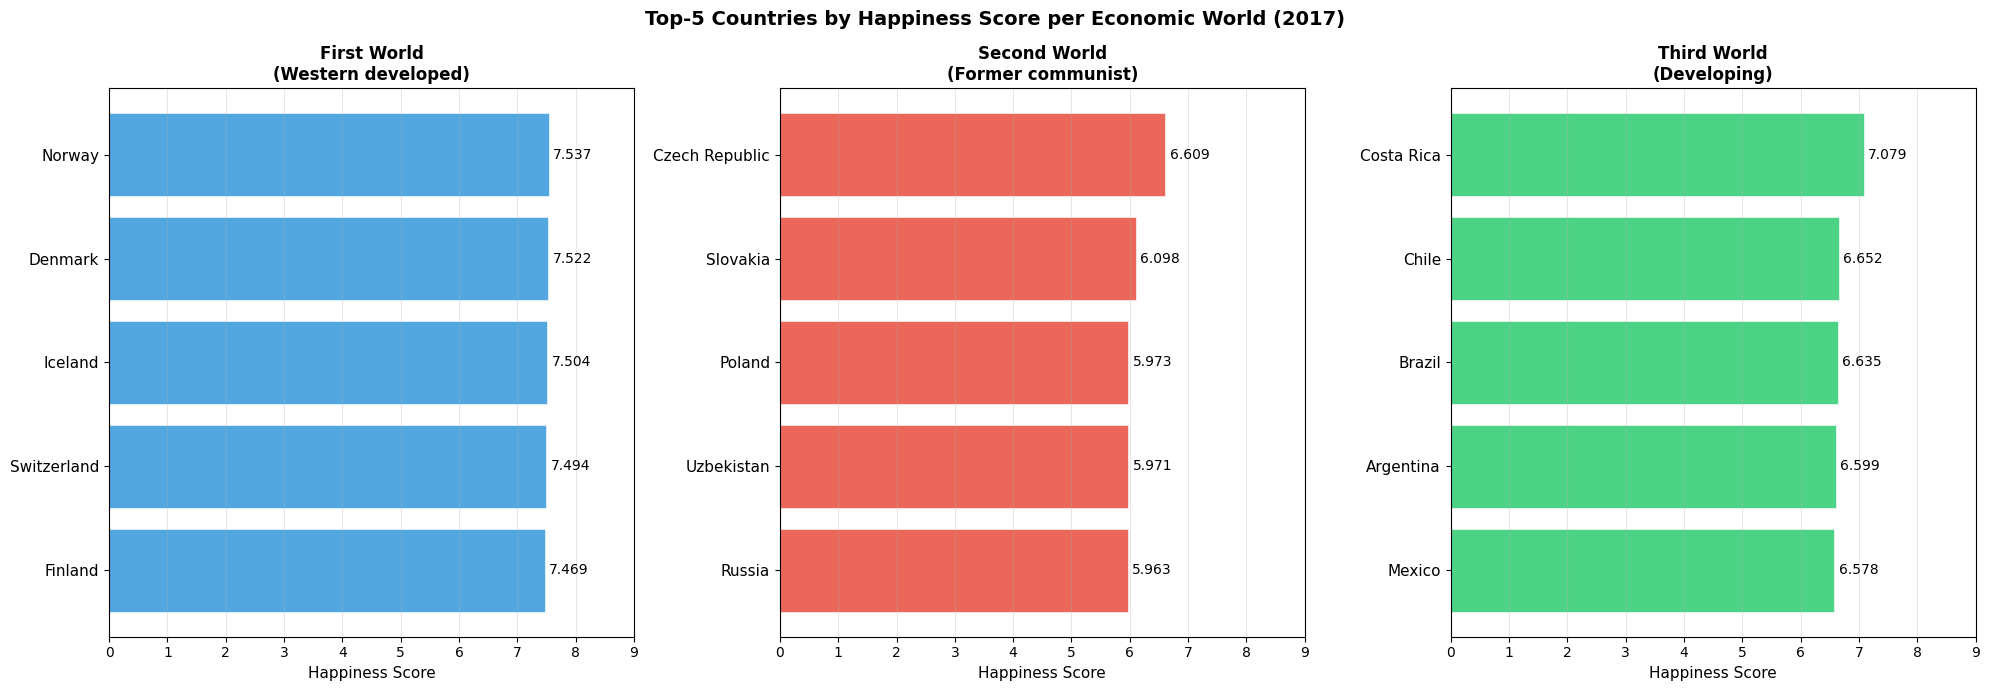

In [10]:
# 5. Набор данных столбец с указанием экономического мира страны и топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров

first_world = {
    'Norway', 'Denmark', 'Iceland', 'Switzerland', 'Finland', 'Netherlands',
    'Canada', 'New Zealand', 'Sweden', 'Australia', 'Israel', 'Austria',
    'United States', 'Ireland', 'Germany', 'Belgium', 'Luxembourg',
    'United Kingdom', 'France', 'Spain', 'Singapore', 'Malta', 'Japan',
    'South Korea', 'Hong Kong S.A.R., China', 'United Arab Emirates',
    'Qatar', 'Kuwait', 'Saudi Arabia', 'Bahrain', 'Taiwan Province of China',
    'Cyprus', 'North Cyprus', 'Portugal', 'Greece', 'Italy',
}

second_world = {
    'Russia', 'China', 'Poland', 'Czech Republic', 'Slovakia', 'Hungary',
    'Romania', 'Bulgaria', 'Lithuania', 'Latvia', 'Estonia', 'Belarus',
    'Slovenia', 'Croatia', 'Serbia', 'Montenegro', 'Kosovo',
    'Bosnia and Herzegovina', 'Albania', 'Macedonia', 'Moldova', 'Ukraine',
    'Kazakhstan', 'Uzbekistan', 'Turkmenistan', 'Kyrgyzstan', 'Tajikistan',
    'Azerbaijan', 'Armenia', 'Georgia', 'Mongolia', 'Vietnam',
}

def assign_world(country):
    if country in first_world:
        return '1st World'
    if country in second_world:
        return '2nd World'
    return '3rd World'

df['Economic_World'] = df['Country'].apply(assign_world)

print('Distribution by economic world:')
print(df['Economic_World'].value_counts())
print()

worlds      = ['1st World', '2nd World', '3rd World']
world_labels = ['First World\n(Western developed)', 'Second World\n(Former communist)', 'Third World\n(Developing)']
world_colors = ['#3498DB', '#E74C3C', '#2ECC71']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top-5 Countries by Happiness Score per Economic World (2017)',
             fontsize=14, fontweight='bold')

for ax, world, wlabel, color in zip(axes, worlds, world_labels, world_colors):
    top5 = df[df['Economic_World'] == world].nlargest(5, 'Happiness.Score')
    bars = ax.barh(range(len(top5)), top5['Happiness.Score'],
                   color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5['Country'], fontsize=11)
    ax.set_title(wlabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('Happiness Score', fontsize=11)
    ax.set_xlim(0, 9)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    for bar, val in zip(bars, top5['Happiness.Score']):
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
